<a href="https://colab.research.google.com/github/thuynguyenhuit/hocsau/blob/main/TrashNet_Project/Phan_loai_rac_thai_bang_mo_hinh_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1. Kết nối dữ liệu trên drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
data_path = '/content/drive/MyDrive/CNN/Garbage_Data'
if os.path.exists(data_path):
    print("Kết nối thành công! Các lớp rác thải tìm thấy:", os.listdir(data_path))
else:
    print("Đường dẫn chưa đúng, bạn hãy kiểm tra lại tên folder trên Drive.")

Kết nối thành công! Các lớp rác thải tìm thấy: ['trash', 'cardboard', 'metal', 'plastic', 'glass', 'paper']


In [2]:
# import các thư viện
import os
import warnings; warnings.filterwarnings("ignore")
# ── Image Processing ─────────────────────────
import cv2 # read/resize images
from tqdm import tqdm # progress bar
# ── Numerical Computing ──────────────────────
import numpy as np
import pandas as pd
# ── Visualisation ────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# ── Deep Learning ────────────────────────────
import tensorflow as tf
import keras
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as keras_image
# ── Evaluation ───────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import shuffle


In [5]:
#Chia tập dữ liệu
import tensorflow as tf

# Đường dẫn dataset
data_dir = "/content/drive/MyDrive/CNN/Garbage_Data"

# Kích thước ảnh
img_size = (224, 224)

# Batch size
batch_size = 64

# =========================
# 1. TRAIN DATASET (70%)
# =========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,      # 30% còn lại
    subset="training",         # lấy 70% train
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# =========================
# 2. TEMP DATASET (30%)
# =========================
temp_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",       # lấy 30%
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# =========================
# 3. CHIA 30% -> 15% VAL + 15% TEST
# =========================
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(temp_batches // 2)

test_ds = temp_ds.skip(temp_batches // 2)

# =========================
# 4. KIỂM TRA SỐ BATCH
# =========================
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Found 2527 files belonging to 6 classes.
Using 758 files for validation.
Train batches: 28
Validation batches: 6
Test batches: 6


In [6]:
#Hiển thị class name
class_names = train_ds.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


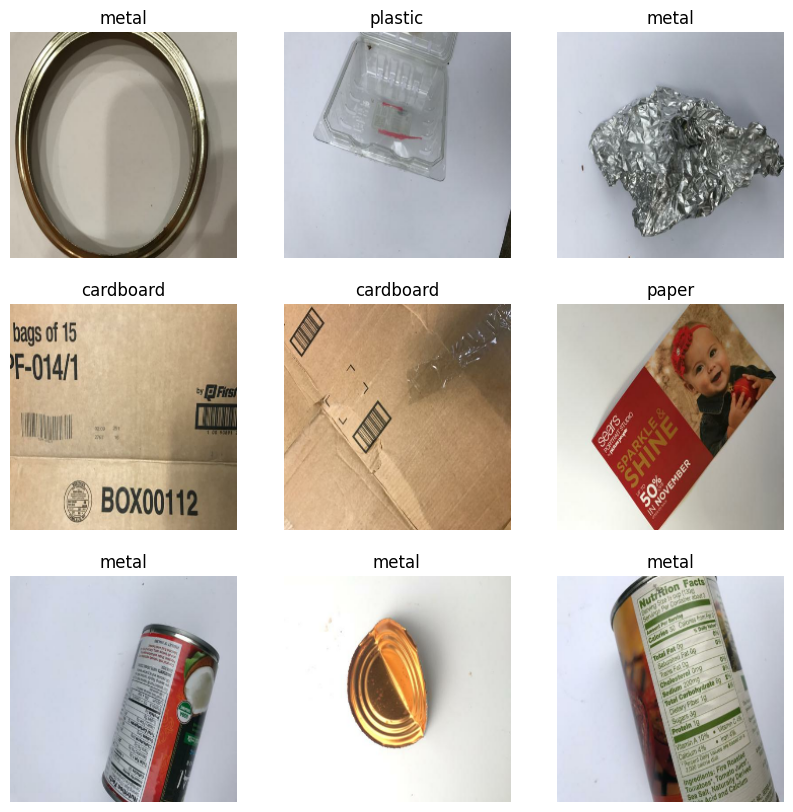

In [7]:
#Hiển thị ảnh
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

In [8]:
#cache(): Lưu dataset vào RAM → đọc nhanh hơn

# shuffle(1000): Trộn dữ liệu → tránh model học theo thứ tự

# prefetch(): Trong lúc GPU train: CPU chuẩn bị batch tiếp theo

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
#Làm giàu dữ liệu
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1),

])

In [9]:
#Tạo mô hình CNN
from tensorflow.keras import models, layers

model = models.Sequential([

    # Làm giàu dữ liệu
    data_augmentation,

    # Chuẩn hóa pixel từ 0-255 -> 0-1
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # CNN Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # CNN Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    # Chuyển feature map thành vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(len(class_names), activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
# Xem kiến trúc model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
#Train model
epochs = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 720s 5s/step - accuracy: 0.2759 - loss: 1.8562 - val_accuracy: 0.3828 - val_loss: 1.4867
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.3901 - loss: 1.4539 - val_accuracy: 0.3932 - val_loss: 1.3697
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4562 - loss: 1.3063 - val_accuracy: 0.5078 - val_loss: 1.2206
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.5410 - loss: 1.1648 - val_accuracy: 0.5677 - val_loss: 1.1393
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.5834 - loss: 1.0624 - val_accuracy: 0.5573 - val_loss: 1.1754
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.6032 - loss: 1.0296 - val_accuracy: 0.6172 - val_loss: 1.0614
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.6444 - loss: 0.9475 - val_accuracy: 0.6406 - val_loss: 1.0101
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.6535 - loss: 0.9388 - val_accuracy: 0.630

In [13]:
#Đánh giá trên test set
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 130s 11s/step - accuracy: 0.6444 - loss: 1.0733
Test Accuracy: 0.644385039806366


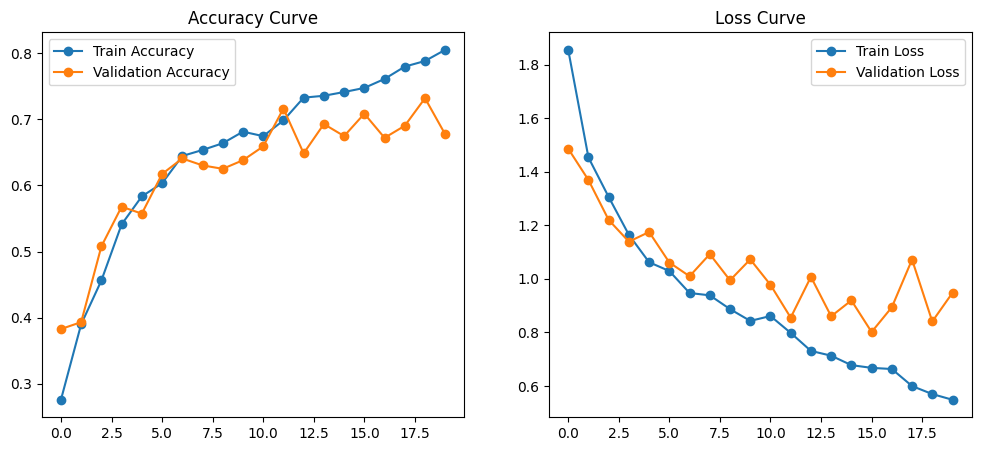

In [14]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Curve
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss Curve
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, marker='o', label='Train Loss')
plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

In [15]:
# Predict trên tập test
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:

    # Dự đoán xác suất
    predictions = model.predict(images)

    # Lấy class có xác suất cao nhất
    predicted_labels = np.argmax(predictions, axis=1)

    # Lưu nhãn thật
    y_true.extend(labels.numpy())

    # Lưu nhãn dự đoán
    y_pred.extend(predicted_labels)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step


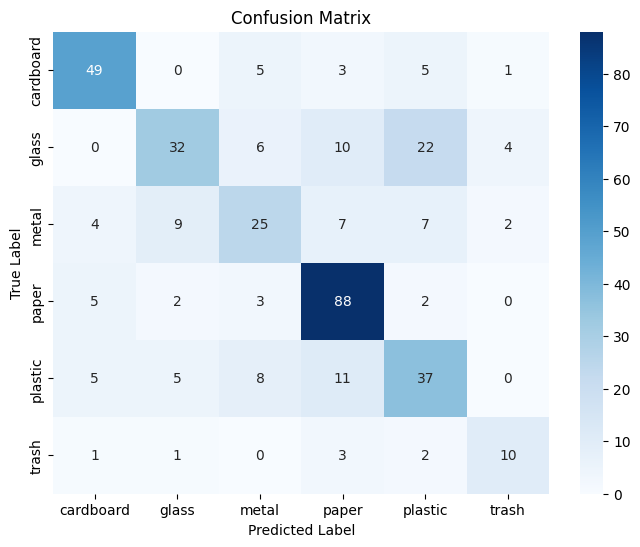

In [16]:
# Vẽ Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Vẽ
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [17]:
#Precision / Recall / F1-score
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

   cardboard       0.77      0.78      0.77        63
       glass       0.65      0.43      0.52        74
       metal       0.53      0.46      0.50        54
       paper       0.72      0.88      0.79       100
     plastic       0.49      0.56      0.52        66
       trash       0.59      0.59      0.59        17

    accuracy                           0.64       374
   macro avg       0.63      0.62      0.62       374
weighted avg       0.64      0.64      0.64       374



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step


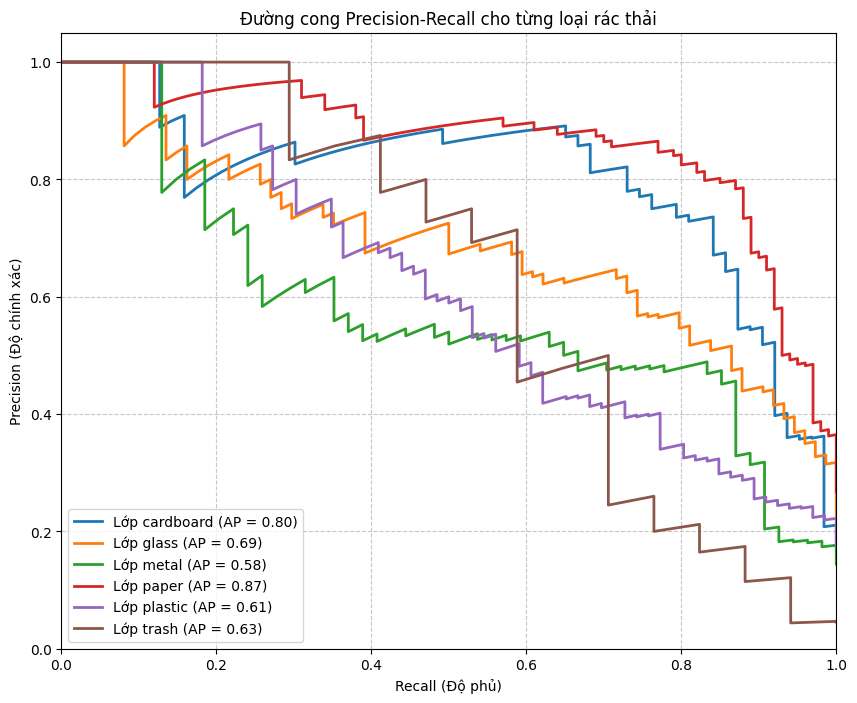

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

# --- BƯỚC 1: CHUẨN BỊ DỮ LIỆU ĐỐI CHIẾU ---

# Tên các lớp để hiển thị trên chú thích (Legend)
class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
n_classes = len(class_names)

# Trích xuất nhãn thực tế (y_true) từ tập test_ds
# Chúng ta duyệt qua dataset một lần để gom tất cả nhãn thật vào mảng numpy
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Dự đoán xác suất (y_score) từ mô hình
# model.predict trả về ma trận (số mẫu x 6 lớp)
y_score = model.predict(test_ds)

# Chuyển đổi nhãn về dạng Binary (One-hot) để vẽ đường cong cho từng lớp
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5])

# --- BƯỚC 2: VẼ BIỂU ĐỒ ---

plt.figure(figsize=(10, 8))

# Vẽ đường cong PR cho từng lớp rác thải
for i in range(n_classes):
    # Tính toán Precision và Recall tại các ngưỡng khác nhau
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])

    # Tính điểm Precision trung bình (Average Precision)
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])

    plt.plot(recall, precision, lw=2,
             label=f'Lớp {class_names[i]} (AP = {ap:.2f})')

# Cấu hình hiển thị biểu đồ
plt.xlabel("Recall (Độ phủ)")
plt.ylabel("Precision (Độ chính xác)")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title("Đường cong Precision-Recall cho từng loại rác thải")
plt.legend(loc="lower left")
plt.grid(True, linestyle='--', alpha=0.7)

# --- BƯỚC 3: LƯU KẾT QUẢ ---
# Tạo thư mục results nếu chưa có để tránh lỗi lưu file
import os
if not os.path.exists('results'):
    os.makedirs('results')

plt.savefig('results/pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


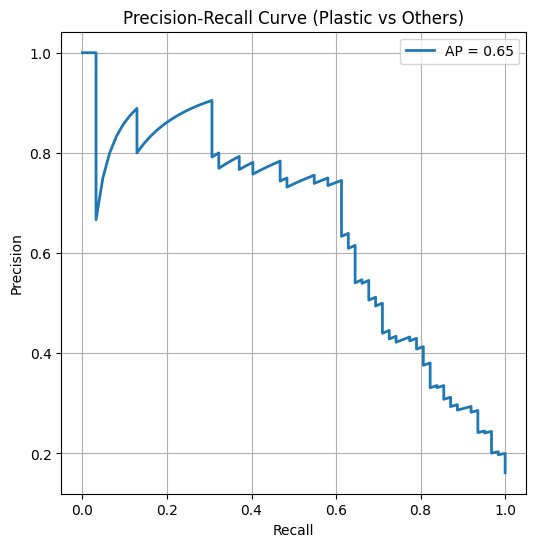

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

# =========================
# Chọn class muốn vẽ
# =========================
target_class = class_names.index("plastic")

# Lưu nhãn thật và xác suất dự đoán
y_true = []
y_scores = []

# =========================
# Duyệt validation set
# =========================
for images, labels in val_ds:

    # Predict xác suất
    predictions = model.predict(images)

    # Lấy xác suất của class plastic
    plastic_scores = predictions[:, target_class]

    # Chuyển nhãn:
    # plastic = 1
    # lớp khác = 0
    binary_labels = (labels.numpy() == target_class).astype(int)

    # Lưu dữ liệu
    y_true.extend(binary_labels)
    y_scores.extend(plastic_scores)

# =========================
# Tính Precision & Recall
# =========================
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_scores
)

# Average Precision Score
ap_score = average_precision_score(y_true, y_scores)

# =========================
# Vẽ PR Curve
# =========================
plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"AP = {ap_score:.2f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve (Plastic vs Others)")

plt.legend()

plt.grid(True)

plt.show()

In [70]:
# CẢI TIẾN MÔ HÌNH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

In [71]:
# =========================
# Chia tập dữ liệu 80-20
# =========================

import tensorflow as tf

# Đường dẫn dataset
data_dir = "/content/drive/MyDrive/CNN/Garbage_Data"

# Kích thước ảnh
img_size = (224, 224)

# Batch size
batch_size = 64

# =========================
# TRAIN DATASET (80%)
# =========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=img_size,

    batch_size=batch_size

)

# =========================
# VALIDATION DATASET (20%)
# =========================
val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=img_size,

    batch_size=batch_size

)

# =========================
# Lấy tên class
# =========================
class_names = train_ds.class_names

print("Classes:", class_names)


# =========================
# Kiểm tra số batch
# =========================
print(
    "Train batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(val_ds).numpy()
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train batches: 32
Validation batches: 8


In [72]:
class_names = train_ds.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [73]:
#Tối ưu hiệu năng
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [74]:
# Tăng cường dữ liệu
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.05)

])

In [75]:
# Tạo mô hình CNN
from tensorflow.keras import models, layers

model = models.Sequential([

    # =========================
    # Data Augmentation
    # =========================
    data_augmentation,

    # =========================
    # Normalize pixel
    # =========================
    layers.Rescaling(1./255),

    # =========================
    # CNN Block 1
    # =========================
    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # =========================
    # CNN Block 2
    # =========================
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # =========================
    # CNN Block 3
    # =========================
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # =========================
    # Flatten
    # =========================
    layers.Flatten(),

    # =========================
    # Dense Layer
    # =========================
    layers.Dense(
        128,
        activation='relu'
    ),

    # =========================
    # Dropout chống overfitting
    # =========================
    layers.Dropout(0.5),

    # =========================
    # Output Layer
    # =========================
    layers.Dense(
        len(class_names),
        activation='softmax'
    )

])

In [76]:
model.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_16 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
# Compile mô hình
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [67]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True

)

In [68]:
# train mô hình
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=[early_stop]

)

Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 379ms/step - accuracy: 0.2789 - loss: 1.6627 - val_accuracy: 0.3762 - val_loss: 1.5182
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 330ms/step - accuracy: 0.3595 - loss: 1.5293 - val_accuracy: 0.3980 - val_loss: 1.4308
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 298ms/step - accuracy: 0.4228 - loss: 1.4585 - val_accuracy: 0.4733 - val_loss: 1.3441
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 318ms/step - accuracy: 0.4446 - loss: 1.3848 - val_accuracy: 0.4693 - val_loss: 1.3008
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 322ms/step - accuracy: 0.4802 - loss: 1.3227 - val_accuracy: 0.5208 - val_loss: 1.2401
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.4881 - loss: 1.2997 - val_accuracy: 0.5287 - val_loss: 1.2101
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - accuracy: 0.5020 - loss: 1.2534 - val_accuracy: 0.5723 - val_loss: 1.1606
Epoch 8/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 340ms/step - accuracy: 0.5193 - loss: 1.2252 - val_accu

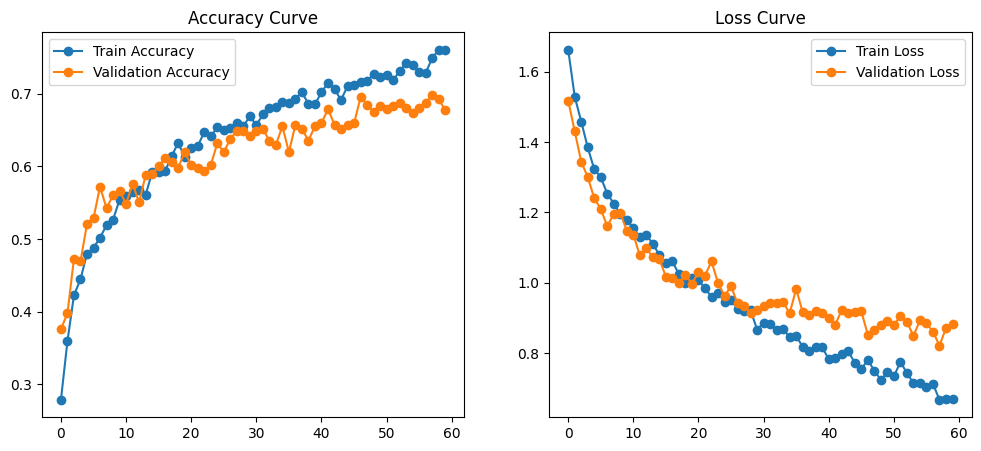

In [69]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# Accuracy Curve
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, marker='o', label='Train Accuracy')
plt.plot(epochs_range, val_acc, marker='o', label='Validation Accuracy')
plt.legend()
plt.title('Accuracy Curve')

# Loss Curve
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, marker='o', label='Train Loss')
plt.plot(epochs_range, val_loss, marker='o', label='Validation Loss')
plt.legend()
plt.title('Loss Curve')

plt.show()

In [15]:
#Cải tiến lần 2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

In [16]:
# =========================
# Chia tập dữ liệu 80-20
# =========================

import tensorflow as tf

# Đường dẫn dataset
data_dir = "/content/drive/MyDrive/CNN/Garbage_Data"

# Kích thước ảnh
img_size = (224, 224)

# Batch size
batch_size = 64

# =========================
# TRAIN DATASET (80%)
# =========================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,

    validation_split=0.2,

    subset="training",

    seed=123,

    image_size=img_size,

    batch_size=batch_size

)

# =========================
# VALIDATION DATASET (20%)
# =========================
val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    data_dir,

    validation_split=0.2,

    subset="validation",

    seed=123,

    image_size=img_size,

    batch_size=batch_size

)

# =========================
# Lấy tên class
# =========================
class_names = train_ds.class_names

print("Classes:", class_names)


# =========================
# Kiểm tra số batch
# =========================
print(
    "Train batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(val_ds).numpy()
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train batches: 32
Validation batches: 8


In [80]:
class_names = train_ds.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [17]:
#Tối ưu hiệu năng
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [18]:
# Tăng cường dữ liệu
from tensorflow.keras import layers
import tensorflow as tf

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.05)

])

In [19]:
from tensorflow.keras import models, layers

model = models.Sequential([

    # =========================
    # Data Augmentation
    # =========================
    data_augmentation,

    # =========================
    # Normalize pixel
    # =========================
    layers.Rescaling(1./255),

    # ==================================================
    # BLOCK 1
    # ==================================================
    layers.Conv2D(

        32,

        (3,3),

        padding='same',

        activation='relu'

    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Dropout(0.2),

    # ==================================================
    # BLOCK 2
    # ==================================================
    layers.Conv2D(

        64,

        (3,3),

        padding='same',

        activation='relu'

    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    # ==================================================
    # BLOCK 3
    # ==================================================
    layers.Conv2D(

        128,

        (3,3),

        padding='same',

        activation='relu'

    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(),

    layers.Dropout(0.4),

    # ==================================================
    # GLOBAL AVERAGE POOLING
    # ==================================================
    layers.GlobalAveragePooling2D(),

    # ==================================================
    # DENSE
    # ==================================================
    layers.Dense(

        64,

        activation='relu'

    ),

    layers.Dropout(0.5),

    # ==================================================
    # OUTPUT
    # ==================================================
    layers.Dense(

        len(class_names),

        activation='softmax'

    )

])

In [20]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=0.0001

    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True

)

In [23]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=50,

    callbacks=[early_stop]

)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 363ms/step - accuracy: 0.2888 - loss: 1.8495 - val_accuracy: 0.1545 - val_loss: 1.8049
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step - accuracy: 0.3991 - loss: 1.5638 - val_accuracy: 0.1545 - val_loss: 1.8219
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 387ms/step - accuracy: 0.4288 - loss: 1.4337 - val_accuracy: 0.2475 - val_loss: 1.8231
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 360ms/step - accuracy: 0.4926 - loss: 1.3475 - val_accuracy: 0.1842 - val_loss: 1.8258
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 348ms/step - accuracy: 0.4941 - loss: 1.3304 - val_accuracy: 0.1762 - val_loss: 1.8403
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 352ms/step - accuracy: 0.5227 - loss: 1.2879 - val_accuracy: 0.1723 - val_loss: 1.8434
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 371ms/step - accuracy: 0.5292 - loss: 1.2674 - val_accuracy: 0.1703 - val_loss: 1.8540
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 361ms/step - accuracy: 0.5331 - loss: 1.2417 - val_accu